**Import modules**

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import zipfile as zf
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print('Done importing modules...')

Done importing modules...


In [15]:
# # unzip file

# zip_path = '../data/Python_Diwali_Sales_Analysis.zip'
# extract_path = '../data/'

# with zf.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

In [16]:
# create df
file_path = r'../data/Python_Diwali_Sales_Analysis/Diwali Sales Data.csv'

df = pd.read_csv(file_path, encoding='unicode_escape')

print('Done creating dataframe...')

Done creating dataframe...


**Initial Look at the Data**

**Initial Observation:**

- The dataset contains **11,251 rows and 15 columns.** Missing values are pressent in `Amount`, `Status`, and `unnamed1`. However, it appears that the `Status` and `unnamed1` columns do not have any entry in the dataset.

In [17]:
# df shape
row, col = df.shape

print(f'Number of Rows: {row}')
print(f'Number of Columns: {col}')

# df metadata
df.info()

Number of Rows: 11251
Number of Columns: 15
<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [18]:
# first 5 rows
print('First 5 rows: ')
display(df.head())

# last 5 rows
print('\nLast 5 rows: ')
display(df.tail())

First 5 rows: 


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,"23,952.00",NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,"23,934.00",NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,"23,924.00",NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,"23,912.00",NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,"23,877.00",NaN,NaN



Last 5 rows: 


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.00,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.00,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.00,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.00,NaN,NaN
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188.00,NaN,NaN


In [19]:
# count unique values
df.nunique().sort_values(ascending=False)

Amount              6584
User_ID             3755
Product_ID          2351
Cust_name           1250
Age                   81
Product_Category      18
State                 16
Occupation            15
Age Group              7
Zone                   5
Orders                 4
Marital_Status         2
Gender                 2
Status                 0
unnamed1               0
dtype: int64

In [20]:
# descriptive stats for numerical columns
pd.set_option('display.float_format', '{:,.2f}'.format)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,"11,251.00","1,003,004.49","1,716.13","1,000,001.00","1,001,492.00","1,003,065.00","1,004,430.00","1,006,040.00"
Age,"11,251.00",35.42,12.75,12.00,27.00,33.00,43.00,92.00
Marital_Status,"11,251.00",0.42,0.49,0.00,0.00,0.00,1.00,1.00
Orders,"11,251.00",2.49,1.12,1.00,1.50,2.00,3.00,4.00
Amount,"11,239.00","9,453.61","5,222.36",188.00,"5,443.00","8,109.00","12,675.00","23,952.00"
Status,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unnamed1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Initial Observation:**

* **Age:** The average customer age is **35.42 years**, with a standard deviation of **12.75 years**, indicating considerable variation in customer ages. The median age is **33 years**, meaning that 50% of the customers are aged 33 or below, while the middle 50% of customers are between **27 and 43 years old**. Customer ages range from **12 to 92 years**. Since the mean is higher than the median, the distribution may be **right-skewed**, potentially due to a smaller number of older customers. This should be further examined using a histogram and boxplot.

* **Marital_Status:** The mean value is **0.42**, with a standard deviation of **0.49**. Because this feature is binary, with **0 representing unmarried and 1 representing married customers**, the mean can be interpreted as the proportion of observations coded as 1, approximately **42%**. The median is **0**, while the 75th percentile is **1**, indicating that at least 50% but fewer than 75% of the observations have a value of 0. Since this is a categorical binary variable, skewness is not particularly useful for interpretation. The actual proportions of each category should instead be examined using frequency counts.

* **Orders:** The average number of orders is **2.49**, with a standard deviation of **1.12**, indicating some variation in the number of orders across the records. The median is **2**, meaning that half of the records have 2 or fewer orders and half have 2 or more orders. The middle 50% of observations fall between **1.5 and 3 orders**, while the values range from **1 to 4 orders**. Since `Orders` is a discrete count variable with only four possible values, its distribution would be more appropriately examined using frequency counts or a bar chart.

* **Amount:** The average transaction amount is **9,453.61**, with a standard deviation of **5,222.36**, indicating considerable variation in transaction amounts. The median is **8,109**, which is lower than the mean and suggests that the distribution may be **right-skewed**, with some transactions having relatively high values. The middle 50% of transaction amounts range from **5,443 to 12,675**, while the values range from **188 to 23,952**. A histogram and boxplot should be used to further examine the distribution and identify potential outliers.

* **User_ID:** The `User_ID` values range from **1,000,001 to 1,006,040**. Since this column serves as an identifier rather than a meaningful numerical measurement, its mean, standard deviation, and percentiles do not provide useful analytical insight. It should therefore be excluded from numerical distribution analysis.

* **Status and unnamed1:** Both columns contain **0 non-null values**, meaning they are completely empty. They provide no usable information for the analysis and can be removed during data cleaning.

In [21]:
# descriptive stats for categorical columns
df.describe(include='object').T.sort_values(by ='freq', ascending=False)

,count,unique,top,freq
Gender,11251,2,F,7842
Age Group,11251,7,26-35,4543
Zone,11251,5,Central,4296
Product_Category,11251,18,Clothing & Apparel,2655
State,11251,16,Uttar Pradesh,1946
Occupation,11251,15,IT Sector,1588
Product_ID,11251,2351,P00265242,53
Cust_name,11251,1250,Vishakha,42


**Exploratory Data Analysis**

In [22]:
# to prevent alteration
df_copy = df.copy()

# drop status and unnamed1 columns
df_copy = df_copy.drop(columns=['Status', 'unnamed1'])
print('Successfully dropped columns... \n')

# display df copy's metadata
display(df_copy.info())

Successfully dropped columns... 

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 1.1 MB


None

In [23]:
# inspect data types
df_copy.dtypes

User_ID               int64
Cust_name               str
Product_ID              str
Gender                  str
Age Group               str
Age                   int64
Marital_Status        int64
State                   str
Zone                    str
Occupation              str
Product_Category        str
Orders                int64
Amount              float64
dtype: object

In [24]:
# Inspect fractional components of Amount
print('Fractional components in Amount:')
display(df_copy['Amount'].dropna().mod(1).value_counts().sort_index())
print('\n' + "=====" * 10)


# Count Amount values with a fractional component
decimal_amounts = df_copy['Amount'].dropna()[df_copy['Amount'].dropna() % 1 != 0]

print(f'\nNumber of decimal values: {len(decimal_amounts)}')
print(f'Percentage: {len(decimal_amounts) / df_copy["Amount"].notna().sum() * 100:.2f}%')

Fractional components in Amount:


Amount
0.00    11234
0.45        1
0.50        2
0.99        2
Name: count, dtype: int64



Number of decimal values: 5
Percentage: 0.04%


**Initial Observation:**

* **Age Group:** The feature is currently stored as an `object` data type. Since it represents categorical age ranges, it will be treated as a categorical feature and can be used to analyze customer demographics and purchasing behavior across age groups.

* **Amount:** The feature is stored as `float64`. The vast majority of values are whole numbers, with only 5 out of 11,239 non-null values containing decimal components (0.04%). Since these values are non-null observations and there is no evidence that the decimal values are invalid, the original values will be retained without conversion or rounding to avoid altering the data.

* **Status and unnamed1:** Both features contained no data points (0 non-null values) and provided no usable information for the analysis. These columns were therefore removed from the dataset.


**Data Quality**

In [25]:
# check if df has duplicates
has_duplicates = df_copy.duplicated().any()
print(f'Are there duplicates in the dataset?: {has_duplicates}')

duplicate_count = df_copy.duplicated().sum()
print(f'Number of duplicates: {duplicate_count}')

Are there duplicates in the dataset?: True
Number of duplicates: 8


In [26]:
# inspect duplicates
df_copy[df_copy.duplicated()]

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
19,1001883,Praneet,P00029842,M,51-55,54,1,Uttar Pradesh,Central,Hospitality,Auto,1,"23,568.00"
4404,1004725,Jackson,P00150842,F,36-45,37,1,Maharashtra,Western,Hospitality,Electronics & Gadgets,4,"9,859.00"
5703,1003208,Bowman,P00171642,F,26-35,31,0,Bihar,Eastern,Agriculture,Electronics & Gadgets,4,"8,088.00"
5908,1001260,Dheeraj,P00344042,M,26-35,28,0,Maharashtra,Western,IT Sector,Electronics & Gadgets,4,"8,015.00"
6173,1001325,Reese,P00111742,F,26-35,27,1,Gujarat,Western,Construction,Electronics & Gadgets,3,"7,923.00"
8651,1000083,Gute,P00242842,M,26-35,35,0,Uttar Pradesh,Central,Hospitality,Clothing & Apparel,3,"5,345.00"
8941,1001476,Anudeep,P00036842,M,18-25,25,0,Maharashtra,Western,IT Sector,Clothing & Apparel,4,"5,202.00"
10571,1004404,Rittenbach,P00150142,F,26-35,28,1,Haryana,Northern,Aviation,Electronics & Gadgets,3,"2,304.00"


In [27]:
# Display duplicate rows
# show all instances
duplicates = df[df.duplicated(keep=False)]

display(duplicates)

print("=====" * 10)
print(f"Number of duplicated rows: {len(duplicates)}")

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
18,1001883,Praneet,P00029842,M,51-55,54,1,Uttar Pradesh,Central,Hospitality,Auto,1,"23,568.00",NaN,NaN
19,1001883,Praneet,P00029842,M,51-55,54,1,Uttar Pradesh,Central,Hospitality,Auto,1,"23,568.00",NaN,NaN
4403,1004725,Jackson,P00150842,F,36-45,37,1,Maharashtra,Western,Hospitality,Electronics & Gadgets,4,"9,859.00",NaN,NaN
4404,1004725,Jackson,P00150842,F,36-45,37,1,Maharashtra,Western,Hospitality,Electronics & Gadgets,4,"9,859.00",NaN,NaN
5702,1003208,Bowman,P00171642,F,26-35,31,0,Bihar,Eastern,Agriculture,Electronics & Gadgets,4,"8,088.00",NaN,NaN
5703,1003208,Bowman,P00171642,F,26-35,31,0,Bihar,Eastern,Agriculture,Electronics & Gadgets,4,"8,088.00",NaN,NaN
5907,1001260,Dheeraj,P00344042,M,26-35,28,0,Maharashtra,Western,IT Sector,Electronics & Gadgets,4,"8,015.00",NaN,NaN
5908,1001260,Dheeraj,P00344042,M,26-35,28,0,Maharashtra,Western,IT Sector,Electronics & Gadgets,4,"8,015.00",NaN,NaN
6172,1001325,Reese,P00111742,F,26-35,27,1,Gujarat,Western,Construction,Electronics & Gadgets,3,"7,923.00",NaN,NaN
6173,1001325,Reese,P00111742,F,26-35,27,1,Gujarat,Western,Construction,Electronics & Gadgets,3,"7,923.00",NaN,NaN


Number of duplicated rows: 16


In [28]:
# remove duplicates
df_copy = df_copy.drop_duplicates()
print('Successfully dropped duplicates in the dataframe copy... \n')

# display update
print(f'\nRows after removing duplicates: {len(df_copy)}')
print(f'Remaining duplicate rows: {df_copy.duplicated().sum()}')

Successfully dropped duplicates in the dataframe copy... 


Rows after removing duplicates: 11243
Remaining duplicate rows: 0


**Remarks:**

Duplicate Records: The dataset initially contained 8 duplicate occurrences, representing 16 rows in 8 identical pairs. The duplicated records were verified by comparing all columns and confirmed to be exact duplicates. The duplicate rows were removed to prevent the same transactions from being counted more than once during analysis.

In [29]:
# Inspect missing/null values
print('Check whether each column has missing/null values:')
print(df_copy.isnull().any().sort_values(ascending=False))

print("=====" * 10)

print('Check the number of missing/null values per column:')
print(df_copy.isnull().sum().sort_values(ascending=False))

Check whether each column has missing/null values:
Amount               True
User_ID             False
Cust_name           False
Product_ID          False
Gender              False
Age Group           False
Age                 False
Marital_Status      False
State               False
Zone                False
Occupation          False
Product_Category    False
Orders              False
dtype: bool
Check the number of missing/null values per column:
Amount              12
Cust_name            0
Product_ID           0
Gender               0
User_ID              0
Age Group            0
Age                  0
State                0
Marital_Status       0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
dtype: int64


In [30]:
# dipslay columns with missing/null values
missing = df_copy[df_copy.isnull().any(axis=1)]
missing

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN
14,1003858,Cano,P00293742,M,46-50,46,1,Madhya Pradesh,Central,Hospitality,Auto,3,NaN
16,1005447,Amy,P00275642,F,46-50,48,1,Andhra Pradesh,Southern,IT Sector,Auto,3,NaN
109,1005265,Sakshi,P00296242,F,46-50,48,1,Delhi,Central,Banking,Footwear & Shoes,1,NaN
111,1005261,Apoorva,P00057942,F,36-45,41,1,Delhi,Central,IT Sector,Footwear & Shoes,2,NaN
184,1005538,Kartik,P00269542,F,46-50,49,1,Karnataka,Southern,Banking,Footwear & Shoes,1,NaN
293,1000326,Jonathan,P00120542,M,51-55,53,0,Gujarat,Western,IT Sector,Footwear & Shoes,3,NaN
344,1002507,Lakshmi,P00045842,F,26-35,35,1,Gujarat,Western,Chemical,Furniture,1,NaN
345,1004498,Srishti,P00030842,F,51-55,55,0,Delhi,Central,Textile,Footwear & Shoes,1,NaN
452,1004601,Gaurav,P00014442,F,36-45,40,1,Madhya Pradesh,Central,Hospitality,Food,4,NaN


In [31]:
# inspect median
amount_by_group = df_copy.groupby(
    ['Product_Category', 'Occupation']
)['Amount'].median().unstack()


display(amount_by_group)

Occupation,Agriculture,Automobile,Aviation,Banking,Chemical,Construction,Food Processing,Govt,Healthcare,Hospitality,IT Sector,Lawyer,Media,Retail,Textile
Product_Category,,,,,,,,,,,,,,,
Auto,"18,609.00","23,413.50","23,193.00","21,099.50",NaN,"21,172.00","23,239.00","18,970.50","18,995.00","18,679.00","19,295.00","16,738.00","20,939.50","21,200.00","19,280.00"
Beauty,"4,542.50","5,946.00","4,635.00","4,567.50","4,588.00","5,939.00","4,525.00","4,586.00","4,596.00","4,553.00","4,567.00","4,515.00","4,603.50","5,901.00","6,005.00"
Books,"10,240.00","10,364.00","10,301.00","10,329.00","10,521.00","10,570.00","10,262.00","12,844.00","10,609.00","9,280.50","10,599.00","10,225.00","9,206.50","10,232.00","11,650.00"
Clothing & Apparel,"6,976.00","6,947.50","6,923.00","6,924.00","6,940.50","6,889.00","6,912.00","6,887.00","6,942.00","6,885.00","6,925.00","6,884.00","6,898.00","6,915.00","6,890.00"
Decor,"7,028.50","9,908.00","7,009.50","8,036.50","7,797.50","6,122.00","7,912.00","6,040.00","8,032.00","8,046.00","7,888.00","6,111.00","6,980.00","5,835.00","9,989.00"
Electronics & Gadgets,"7,893.50","7,909.50","7,865.00","7,939.00","7,961.00","6,975.00","7,917.50","7,884.00","7,905.50","7,884.50","7,912.00","7,980.00","7,968.50","7,774.00","7,848.00"
Food,"13,655.00","15,289.00","15,275.00","15,227.00","15,246.00","15,273.00","12,013.00","15,247.00","15,236.00","12,040.00","15,234.00","15,201.50","15,251.00","15,235.00","15,296.50"
Footwear & Shoes,"12,758.00","16,456.00","16,415.50","16,356.00","16,495.00","12,854.00","16,448.00","16,283.00","12,823.00","12,790.50","16,197.00","14,510.50","16,420.50","16,543.50","16,550.00"
Furniture,"16,456.00","16,051.00","15,952.00","16,163.00","16,533.00","16,349.00","18,267.00","16,649.50","16,072.50","16,357.00","16,376.00","16,075.00","16,071.50","16,435.00","14,401.50"


In [32]:
category_medians = df_copy.groupby('Product_Category')['Amount'].median()


display(
    category_medians.loc[
        ['Auto', 'Footwear & Shoes', 'Furniture', 'Food']
    ]
)

Product_Category
Auto               19,287.50
Footwear & Shoes   16,289.00
Furniture          16,277.50
Food               15,232.00
Name: Amount, dtype: float64

In [33]:
# identify rows where amount is missing
missing_amount = df_copy[df_copy['Amount'].isnull()].copy()

# calculate the median amount for each Product Category
# and use it to propose a replacement value for each missing Amount
missing_amount['Proposed_Amount'] = (
    missing_amount['Product_Category']
    .map(df_copy.groupby('Product_Category')['Amount'].median())
)

# Display the missing Amount values alongside their proposed replacements
display(
    missing_amount[
        ['Product_Category', 'Occupation', 'Orders', 'Amount', 'Proposed_Amount']
    ]
)

,Product_Category,Occupation,Orders,Amount,Proposed_Amount
7,Auto,IT Sector,1,NaN,"19,287.50"
14,Auto,Hospitality,3,NaN,"19,287.50"
16,Auto,IT Sector,3,NaN,"19,287.50"
109,Footwear & Shoes,Banking,1,NaN,"16,289.00"
111,Footwear & Shoes,IT Sector,2,NaN,"16,289.00"
184,Footwear & Shoes,Banking,1,NaN,"16,289.00"
293,Footwear & Shoes,IT Sector,3,NaN,"16,289.00"
344,Furniture,Chemical,1,NaN,"16,277.50"
345,Footwear & Shoes,Textile,1,NaN,"16,289.00"
452,Food,Hospitality,4,NaN,"15,232.00"


**Remarks:**

Upon inspecting the missing values and their related information, the 12 missing values in the `Amount` column will be imputed using the median `Amount` of their respective `Product_Category`.


In [34]:
# perform imputation on missing values
df_copy['Amount'] = df_copy['Amount'].fillna(
    df_copy['Product_Category'].map(category_medians)
)

print('Missing Amount values after imputation:')
print(df_copy['Amount'].isnull().sum())

Missing Amount values after imputation:
0


In [35]:
# verify 12 rows after imputation
display(
    df_copy.loc[
        missing_amount.index,
        ['Product_Category', 'Occupation', 'Orders', 'Amount']
    ]
)

,Product_Category,Occupation,Orders,Amount
7,Auto,IT Sector,1,"19,287.50"
14,Auto,Hospitality,3,"19,287.50"
16,Auto,IT Sector,3,"19,287.50"
109,Footwear & Shoes,Banking,1,"16,289.00"
111,Footwear & Shoes,IT Sector,2,"16,289.00"
184,Footwear & Shoes,Banking,1,"16,289.00"
293,Footwear & Shoes,IT Sector,3,"16,289.00"
344,Furniture,Chemical,1,"16,277.50"
345,Footwear & Shoes,Textile,1,"16,289.00"
452,Food,Hospitality,4,"15,232.00"


**Numerical Univariate Analysis**

- This section aims to understand the distribution, central tendency, variability, and potential outliers of the dataset's numerical features. Each variable will be analyzed individually using descriptive statistics and appropriate visualizations to identify notable patterns and characteristics in the data.


In [37]:
# descriptive stats for numerical variables
num_cols = df_copy[[
    'Age',
    'Orders',
    'Amount',
    'Marital_Status'
]]


summary = pd.DataFrame(
    {
        'Mean': num_cols.mean(),
        'Median': num_cols.median(),
        'Mode': num_cols.mode().iloc[0],
        'Variance': num_cols.var(),
        'Standard Deviation': num_cols.std(),
        'Minimum': num_cols.min(),
        'Maximum': num_cols.max(),
        'Range': num_cols.max() - num_cols.min(),
        'Skewness': num_cols.skew()
    }
)

display((summary).round(2))

,Mean,Median,Mode,Variance,Standard Deviation,Minimum,Maximum,Range,Skewness
Age,35.42,33.00,30.00,162.72,12.76,12.00,92.00,80.00,1.18
Orders,2.49,2.00,2.00,1.24,1.11,1.00,4.00,3.00,0.02
Amount,"9,461.90","8,111.00","7,907.00","27,296,917.23","5,224.65",188.00,"23,952.00","23,764.00",0.55
Marital_Status,0.42,0.00,0.00,0.24,0.49,0.00,1.00,1.00,0.32


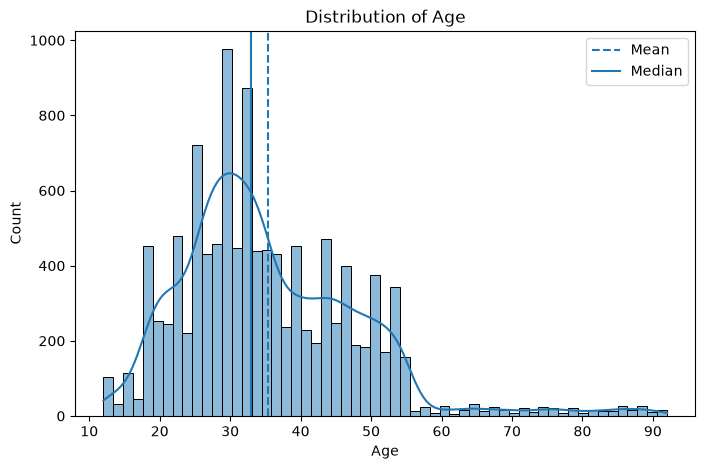

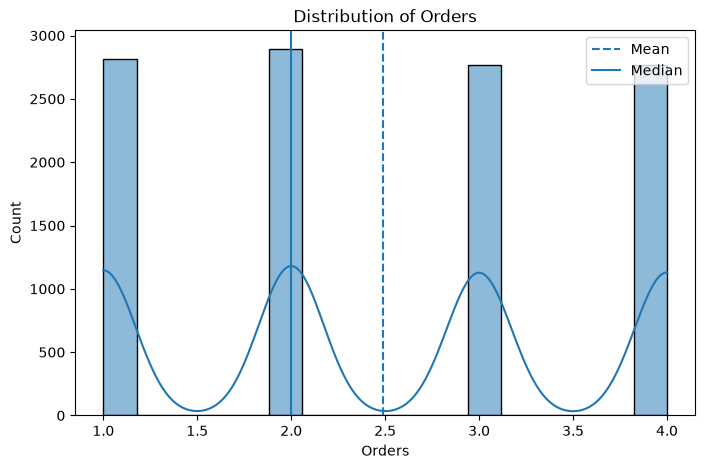

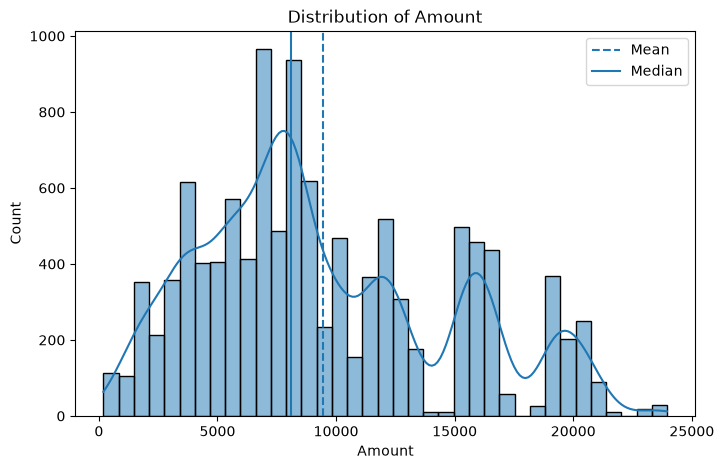

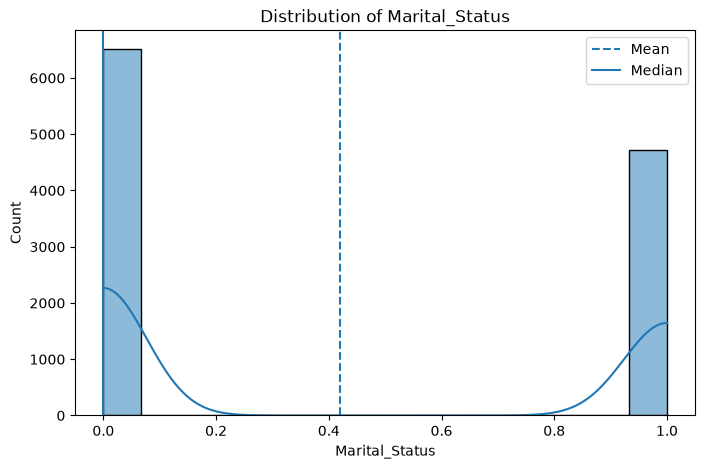

In [36]:
# plot histogram
num_cols = [
    'Age',
    'Orders',
    'Amount',
    'Marital_Status'
]

for col in num_cols:

  plt.figure(figsize=(8,5))

  sns.histplot(data=df_copy, x=col, kde=True)

  plt.axvline(df_copy[col].mean(), linestyle='--', label='Mean')
  plt.axvline(df_copy[col].median(), linestyle='-', label='Median')

  plt.title(f'Distribution of {col}')
  plt.legend()
  plt.show()

In [38]:
# identifying outliers
def main():

  identify_outliers()


def identify_outliers():

  q1 = num_cols.quantile(0.25)
  q3 = num_cols.quantile(0.75)

  iqr = q3 - q1

  lower_limit = q1 - 1.5 * iqr
  upper_limit = q3 + 1.5 * iqr

  for col in num_cols:

    lower_outliers = num_cols[col][num_cols[col] < lower_limit[col]]

    upper_outliers = num_cols[col][num_cols[col] > upper_limit[col]]

    print(f'\n {col}')

    print(f'Lower Limit: {lower_limit[col]}')
    print(f'Lower Outliers: {lower_outliers.tolist()}')


    print(f'Upper Limit: {upper_limit[col]}')
    print(f'Upper Outliers: {upper_outliers.tolist()}')


main()


 Age
Lower Limit: 3.0
Lower Outliers: []
Upper Limit: 67.0
Upper Outliers: [83, 72, 72, 83, 77, 87, 79, 71, 88, 88, 72, 82, 87, 92, 72, 71, 90, 92, 90, 75, 82, 71, 81, 73, 84, 76, 82, 86, 92, 87, 89, 68, 87, 91, 77, 85, 76, 68, 81, 75, 82, 70, 81, 90, 77, 87, 91, 80, 76, 73, 75, 74, 79, 89, 69, 79, 86, 75, 85, 70, 78, 72, 79, 80, 85, 82, 82, 88, 80, 76, 77, 90, 74, 78, 87, 92, 69, 69, 79, 74, 68, 92, 74, 72, 81, 69, 75, 88, 83, 90, 84, 86, 70, 75, 78, 89, 83, 88, 76, 85, 89, 80, 68, 82, 80, 88, 70, 84, 84, 83, 68, 88, 76, 90, 85, 84, 78, 85, 77, 89, 86, 76, 76, 89, 87, 86, 79, 69, 71, 79, 87, 68, 76, 79, 85, 86, 81, 73, 87, 69, 78, 74, 87, 87, 89, 83, 71, 88, 70, 88, 85, 84, 69, 73, 89, 78, 76, 86, 68, 69, 76, 91, 76, 77, 77, 87, 69, 90, 86, 75, 85, 90, 74, 68, 71, 83, 76, 87, 86, 80, 87, 74, 73, 75, 88, 70, 91, 81, 68, 68, 71, 73, 85, 75, 84, 89, 89, 91, 68, 76, 76, 82, 86, 68, 83, 73, 89, 79, 90, 69, 74, 75, 79, 70, 72, 84, 84, 80, 69, 73, 81, 85, 89, 85, 71, 69, 84, 72, 74, 72, 73,

In [39]:
# identify number of outliers per numerical col
def main():

  total_outliers()

def total_outliers():

  q1 = num_cols.quantile(0.25)
  q3 = num_cols.quantile(0.75)

  iqr = q3 - q1

  lower_limit = q1 - 1.5 * iqr
  upper_limit = q3 + 1.5 * iqr

  for col in num_cols:

    total_lower_outliers = (num_cols[col] < lower_limit[col]).sum()

    total_upper_outliers = (num_cols[col] > upper_limit[col]).sum()

    print(f'Total number of lower outliers in {col}: {total_lower_outliers} \n')
    print(f'Total number of upper outliers in {col}: {total_upper_outliers} \n')


main()

Total number of lower outliers in Age: 0 

Total number of upper outliers in Age: 283 

Total number of lower outliers in Orders: 0 

Total number of upper outliers in Orders: 0 

Total number of lower outliers in Amount: 0 

Total number of upper outliers in Amount: 16 

Total number of lower outliers in Marital_Status: 0 

Total number of upper outliers in Marital_Status: 0 



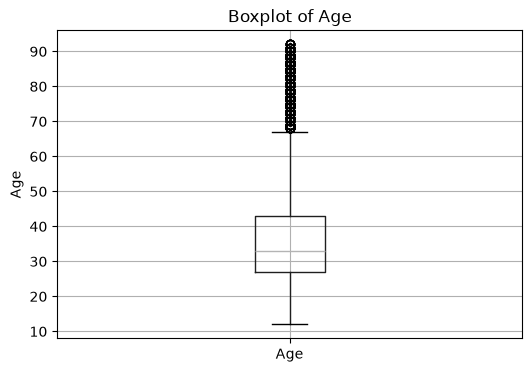

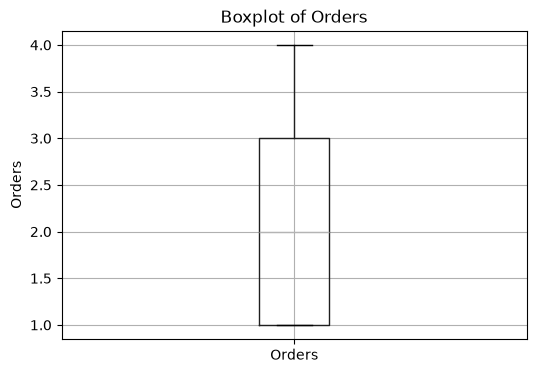

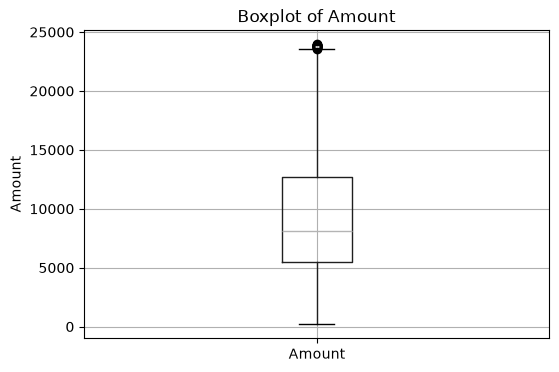

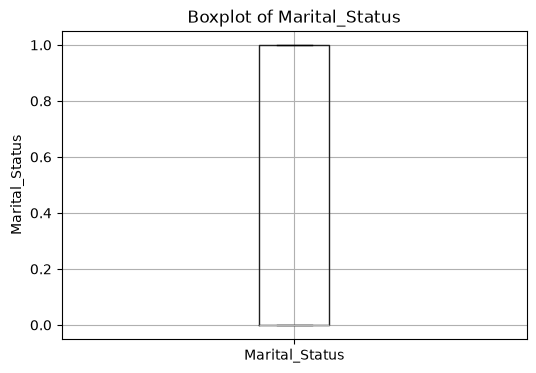

In [40]:
# plot boxplot

for col in num_cols:

  plt.figure(figsize=(6,4))

  df_copy.boxplot(column=[col])

  plt.title(f'Boxplot of {col}')
  plt.ylabel(col)
  plt.show()

**Interpretation:**

- `Age:` The age distribution is right-skewed, indicating a longer tail toward higher ages. The mode is 30, meaning that age 30 is the most frequently occurring individual age in the dataset. The mean age is higher than the median, which is consistent with the right-skewed distribution. Using the IQR method, the upper bound is 67, and ages above this value are identified as potential outliers. A total of 283 age observations were identified as upper outliers. The lower bound is 3, with no lower outliers identified.

- `Orders:` The distribution of Orders is approximately symmetric, with a skewness of 0.02, which is very close to zero. No potential outliers were identified using the IQR method. Since Orders is a discrete count variable ranging from 1 to 4, the number of orders per customer is concentrated within this limited range.

- `Amount:` The distribution of transaction amounts is positively skewed, with a skewness of 0.55. The mode is 7,907, meaning that 7,907 is the most frequently occurring transaction amount. Transaction amounts range from 188 to 23,952. Using the IQR method, the upper bound is 23,567.75, and 16 observations were identified above this threshold. These observations can therefore be considered potential unusually high transaction amounts.

- `Marital_Status:` Marital Status is a binary variable with values of 0 and 1. The mean of 0.42 indicates that approximately 42% of observations have a value of 1, while approximately 58% have a value of 0. The median and mode are both 0, indicating that 0 is the more frequently occurring marital-status category. The standard deviation of 0.49 reflects the variability expected from a binary variable, while the minimum and maximum values confirm that the variable contains only two categories, 0 and 1.


**Categorical Univariate Analysis**

- This section aims to understand the distribution and frequency of the dataset's categorical features. Each variable will be analyzed individually using frequency counts and appropriate visualizations to identify the most common categories, less represented groups, and notable patterns within the data.

For each categorical variable, the analysis will examine:

  - The number of unique categories.
  - The frequency and proportion of observations within each category.
  - The most and least represented categories.
  - Potentially imbalanced or highly concentrated categories.
  - Notable patterns that may help describe customer demographics, purchasing - behavior, and sales characteristics.

In [41]:
# how many observations belong to each category
cat_cols = (
    df_copy.select_dtypes(include='object')
    .drop(columns=['Cust_name', 'Product_ID'])
    .columns
    .tolist()
)

for col in cat_cols:

  print("=====" * 10)

  print(df_copy[col].value_counts(), '\n')
  print(f'Number of unique values in {col}: ', df_copy[col].nunique())

Gender
F    7838
M    3405
Name: count, dtype: int64 

Number of unique values in Gender:  2
Age Group
26-35    4538
36-45    2285
18-25    1878
46-50     987
51-55     831
55+       428
0-17      296
Name: count, dtype: int64 

Number of unique values in Age Group:  7
State
Uttar Pradesh       1944
Maharashtra         1523
Karnataka           1305
Delhi               1107
Madhya Pradesh       923
Andhra Pradesh       812
Himachal Pradesh     608
Kerala               453
Haryana              451
Bihar                433
Gujarat              428
Jharkhand            380
Uttarakhand          320
Rajasthan            231
Punjab               200
Telangana            125
Name: count, dtype: int64 

Number of unique values in State:  16
Zone
Central     4294
Southern    2695
Western     1951
Northern    1490
Eastern      813
Name: count, dtype: int64 

Number of unique values in Zone:  5
Occupation
IT Sector          1586
Healthcare         1408
Aviation           1309
Banking            11

In [42]:
# calculate percentages

for col in cat_cols:

  print("=====" * 10)

  print(df_copy[col].value_counts(normalize=True).mul(100).round(2))

Gender
F   69.71
M   30.29
Name: proportion, dtype: float64
Age Group
26-35   40.36
36-45   20.32
18-25   16.70
46-50    8.78
51-55    7.39
55+      3.81
0-17     2.63
Name: proportion, dtype: float64
State
Uttar Pradesh      17.29
Maharashtra        13.55
Karnataka          11.61
Delhi               9.85
Madhya Pradesh      8.21
Andhra Pradesh      7.22
Himachal Pradesh    5.41
Kerala              4.03
Haryana             4.01
Bihar               3.85
Gujarat             3.81
Jharkhand           3.38
Uttarakhand         2.85
Rajasthan           2.05
Punjab              1.78
Telangana           1.11
Name: proportion, dtype: float64
Zone
Central    38.19
Southern   23.97
Western    17.35
Northern   13.25
Eastern     7.23
Name: proportion, dtype: float64
Occupation
IT Sector         14.11
Healthcare        12.52
Aviation          11.64
Banking           10.13
Govt               7.60
Hospitality        6.24
Media              5.67
Automobile         5.03
Chemical           4.82
Lawyer    

**Interpretation:**

- `Gender:` The dataset is predominantly composed of female customers, with 69.71% of the observations, while male customers accounts for 30.29%. This indicates that there are substantially more female customers than male customers in the dataset.

- `Age Group:` This feature has 7 unique values, which are 0-17, 18-25, 26-35, 36-45, 46-50, 51-55, and 55 above. The age group that dominates the dataset are the customers ages 26-35, with a count of 4,538, followed by the 36-45 age group with a count of 2,285, followed by 18-25 year olds with a count of 1878, followed by 46-50 year olds with a count of 987, followed by 51-55 with a value of 831, then the 55 above age group with 428 customers, lastly the 0-17 age group with a count of 298. This indicates that most of the customers in this dataset are young adults in their late 20s to mid-30s.

- `State:` The dataset contains customers from 16 different states. Uttar Pradesh has the highest number of customers, with 1,944 observations (17.29%), followed by Maharashtra with 1,523 (13.55%) and Karnataka with 1,305 (11.61%). Delhi accounts for 1,107 customers (9.85%), while Madhya Pradesh has 923 (8.21%). The remaining states each account for less than 7% of the observations. This indicates that the customer base is concentrated in a relatively small number of states, with Uttar Pradesh, Maharashtra, and Karnataka contributing the largest shares of customers.

- `Zone:` The dataset contains 5 geographic zones. The Central zone has the largest customer population, with 4,294 observations (38.19%), followed by the Southern zone with 2,695 (23.97%), the Western zone with 1,951 (17.35%), the Northern zone with 1,490 (13.25%), and the Eastern zone with 813 (7.23%). This shows that the dataset is particularly concentrated in the Central zone, which contains more than one-third of all observations, while the Eastern zone has the smallest customer representation.

- `Occupation:` The dataset contains customers from 15 different occupational groups. IT Sector customers have the highest representation, with 1,586 observations (14.11%), followed by Healthcare with 1,408 (12.52%), Aviation with 1,309 (11.64%), and Banking with 1,139 (10.13%). Government employees account for 854 observations (7.60%), while the remaining occupations each represent less than 7% of the dataset. This indicates that the customer base is distributed across a diverse range of occupations, although IT, Healthcare, Aviation, and Banking customers make up relatively large portions of the dataset.

- `Product Category:` The dataset contains 18 different product categories. Clothing & Apparel is the most frequently observed category, with 2,653 observations (23.60%), followed by Food with 2,493 (22.17%) and Electronics & Gadgets with 2,082 (18.52%). Together, these three categories account for approximately 64.29% of all observations. Footwear & Shoes follows with 1,064 observations, while the remaining categories each account for less than 5% of the dataset. This indicates that customer purchases are heavily concentrated in Clothing & Apparel, Food, and Electronics & Gadgets, while categories such as Hand & Power Tools, Tupperware, Veterinary, and Decor have relatively few observations.


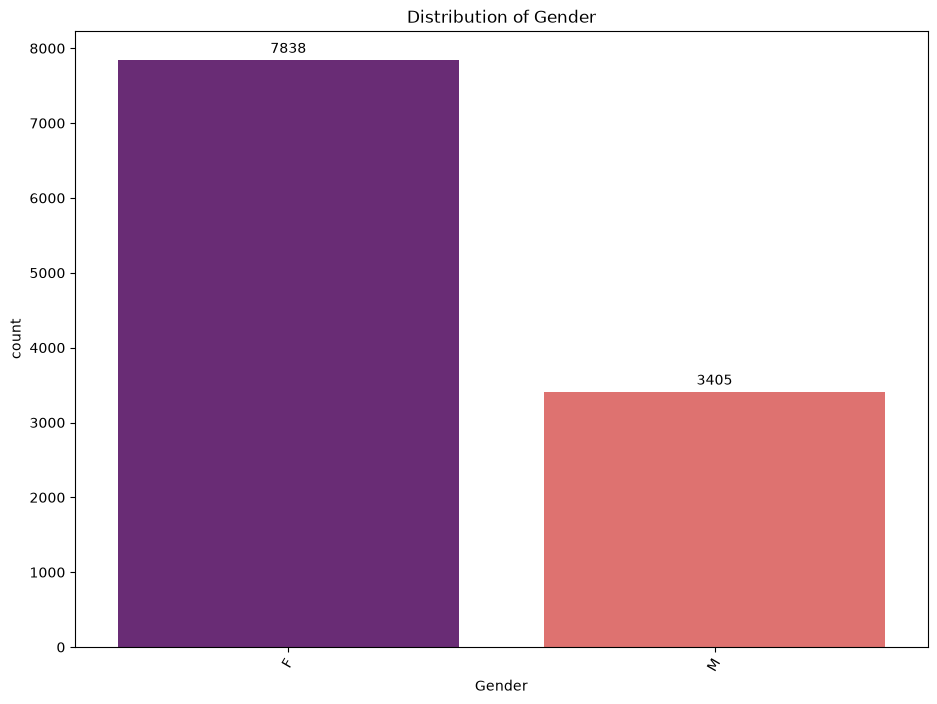

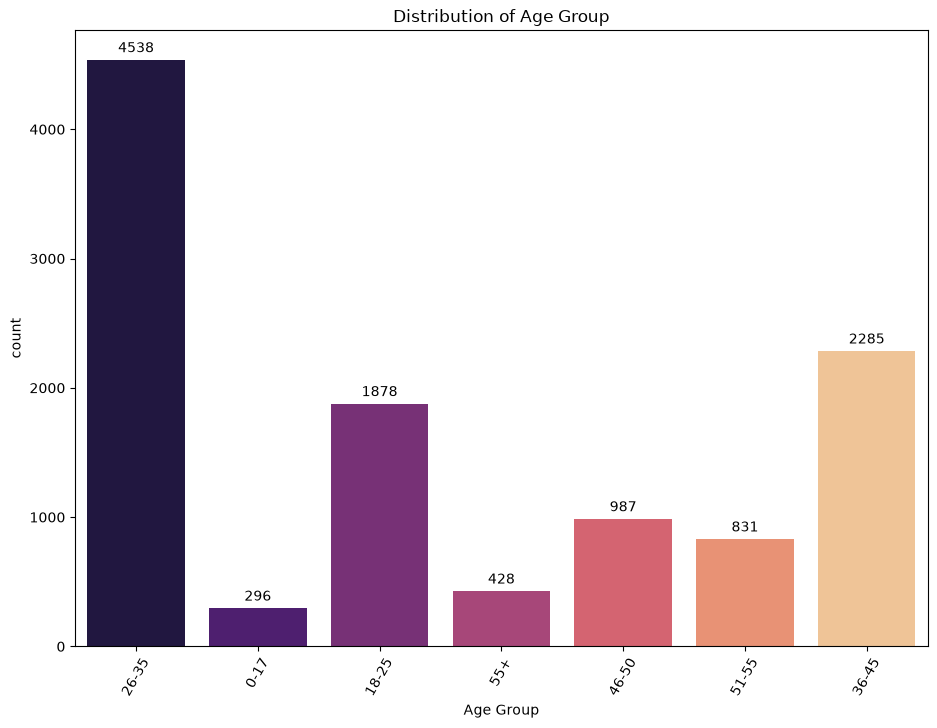

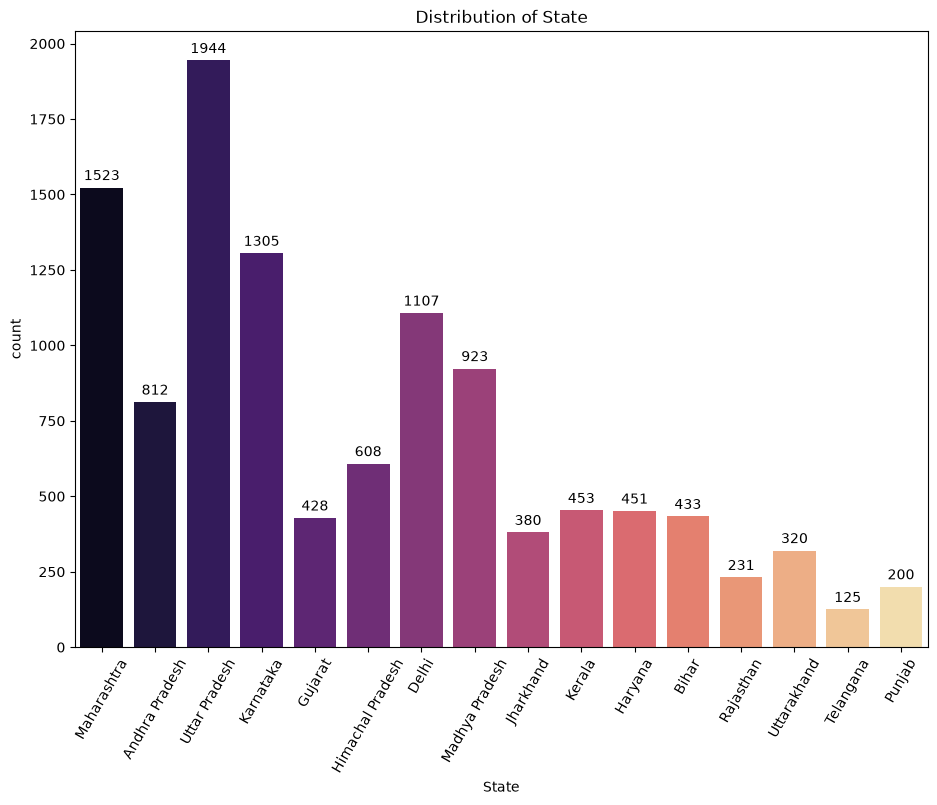

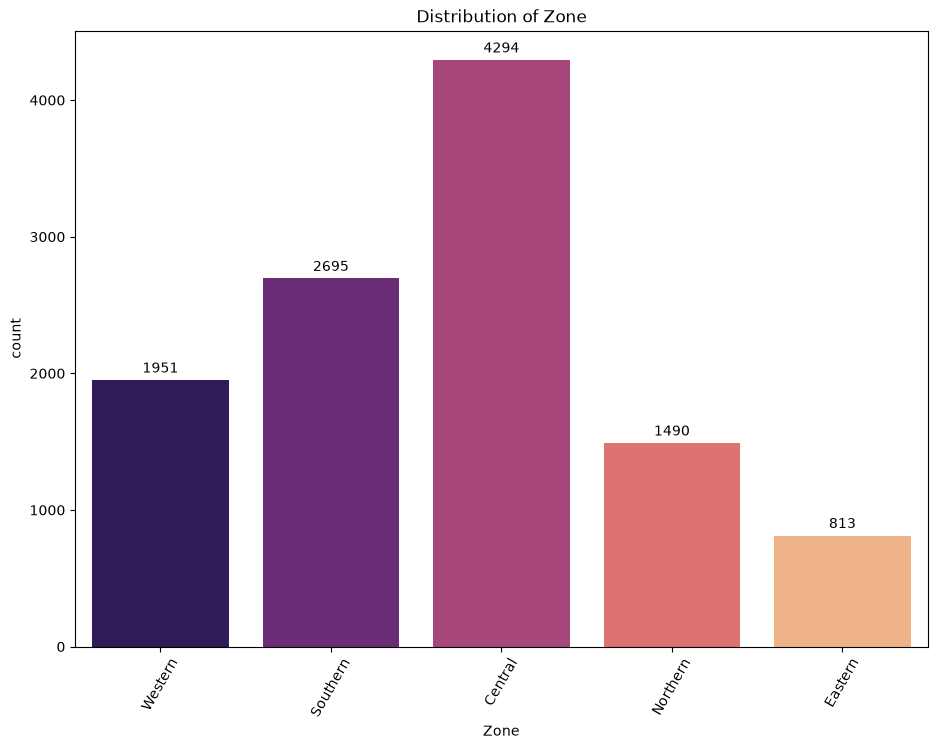

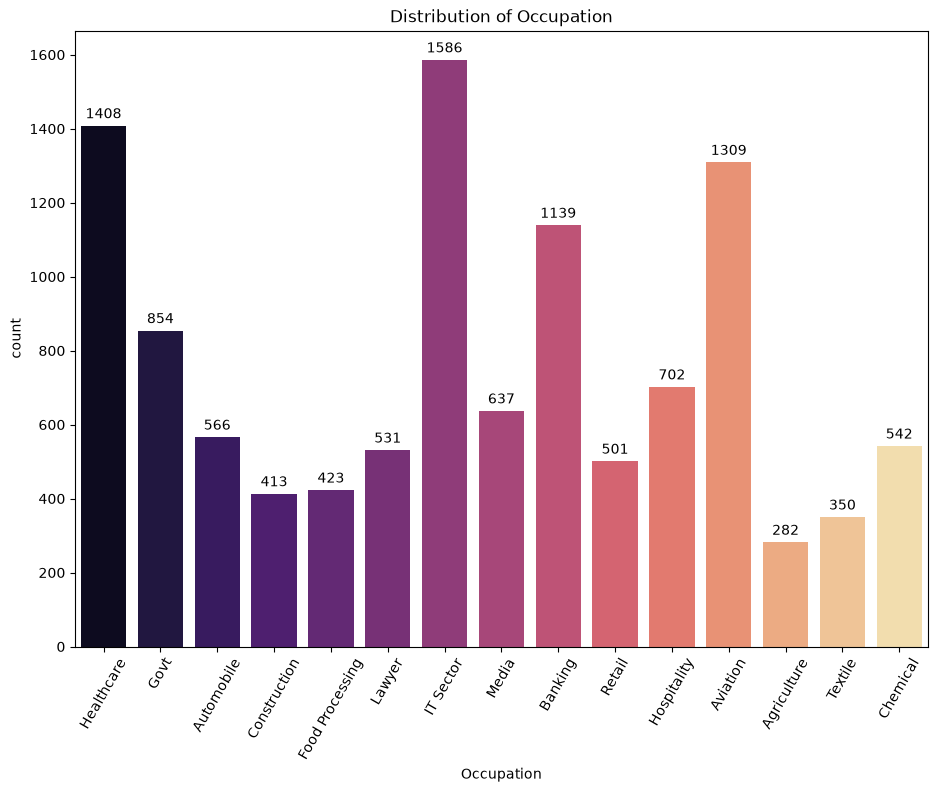

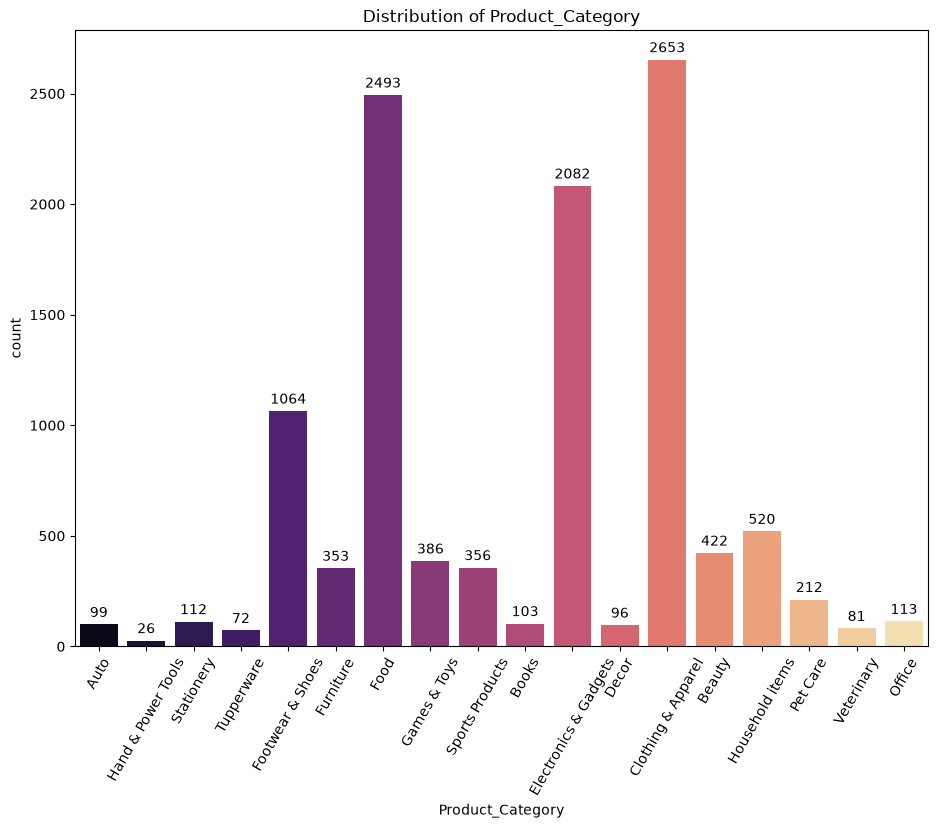

In [43]:
# plot count plots

for col in cat_cols:

  plt.figure(figsize=(11,8))

  ax = sns.countplot(
      data=df_copy,
      x=col,
      palette='magma'
  )

  for container in ax.containers:
    ax.bar_label(container, padding=3)

  plt.title(f'Distribution of {col}')
  plt.xticks(rotation=60)
  plt.show()